<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/ldtqem_20_entanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

════════════════════════════════════════════════════════════════════════════════
  DTQEM v20.0 — Entanglement Decay Results
════════════════════════════════════════════════════════════════════════════════
 T (K)  E_ext  τ_ent (μs)  τ_fit (μs)  C_max  CHSH₀  γ_phi (s⁻¹)      Regime
0.0100 0.0000   1000.0000   1049.8208 1.0000 2.8284       0.0000 underdamped
0.0100 0.3000    953.2554    778.8710 1.0000 2.8284      89.2857 underdamped
0.0100 0.7000    716.1937    667.1289 1.0000 2.8284     208.3333 underdamped
0.0100 1.0000    622.7045    620.1850 1.0000 2.8284     297.6190 underdamped
0.1000 0.0000    964.9416    781.5034 1.0000 2.8284       0.0000 underdamped
0.1000 0.3000    732.8881    655.3891 1.0000 2.8284      89.2857 underdamped
0.1000 0.7000    587.6461    617.3377 1.0000 2.8284     208.3333 underdamped
0.1000 1.0000    522.5376    603.6696 1.0000 2.8284     297.6190 underdamped
1.0000 0.0000     95.1586     83.1450 1.0000 2.8284       0.0000 underdamped
1.0000 0.3000     91.8197

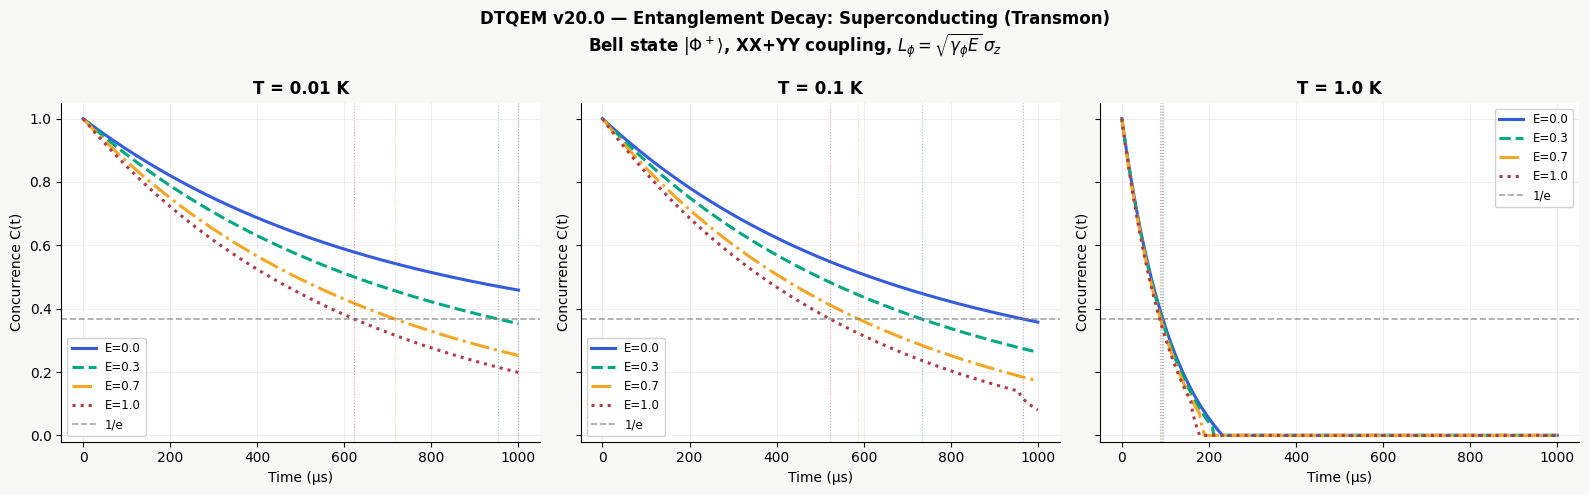

✅ Figure saved: dtqem_v20_entanglement.png


In [1]:

"""
DTQEM v20.0 – Entanglement Lifetime Simulator
===============================================
- Exact two-qubit Lindblad dynamics with T1, T_phi, and thermal noise
- Observer strength E_ext controls pure dephasing only (fixed Hamiltonian)
- Automatic t_max estimation based on the slowest rate
- Exponential fitting for entanglement lifetime τ_fit
- Regime classification: underdamped / overdamped
- Outputs summary table and publication‑ready plots

Author: Reddouane Berramdane (DTQEM Team)
License: CC BY-NC 4.0
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.constants import hbar as HBAR_SI, k as KB_SI
from scipy.optimize import curve_fit
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

# ============================================================================
# 1. Physical constants and Pauli matrices
# ============================================================================
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sp = np.array([[0, 1], [0, 0]], dtype=complex)
sm = np.array([[0, 0], [1, 0]], dtype=complex)
I2 = np.eye(2, dtype=complex)

# ============================================================================
# 2. Qubit database (experimental parameters)
# ============================================================================
qubit_types = {
    "Trapped Ion": {
        "T1": 50.0,                     # s
        "T2": 5.0,                      # s
        "omega0": 2 * np.pi * 1e14,     # rad/s
        "description": "High coherence, ideal for quantum memory"
    },
    "Superconducting (Transmon)": {
        "T1": 1.68e-3,                  # 1.68 ms
        "T2": 1.68e-3,                  # 1.68 ms
        "omega0": 2 * np.pi * 5e9,      # 5 GHz
        "description": "State-of-the-art transmon"
    },
    "Superconducting (Processor)": {
        "T1": 87.6e-6,                  # 87.6 μs
        "T2": 5.1e-6,                   # 5.1 μs
        "omega0": 2 * np.pi * 5e9,
        "description": "Typical 66-qubit processor"
    },
    "Silicon Spin": {
        "T1": 9.5,                      # s
        "T2": 1.9e-3,                   # 1.9 ms
        "omega0": 2 * np.pi * 10e9,     # 10 GHz
        "description": "Silicon spin qubit"
    },
    "Quantum Dot (hole)": {
        "T1": 0.5e-6,                   # 0.5 μs
        "T2": 535e-9,                   # 535 ns
        "omega0": 2 * np.pi * 100e9,    # 100 GHz
        "description": "InAs quantum dot"
    },
}

# ============================================================================
# 3. Helper functions
# ============================================================================
def thermal_n(omega: float, T: float) -> float:
    """Bose-Einstein occupation number."""
    if T <= 0:
        return 0.0
    x = HBAR_SI * omega / (KB_SI * T)
    return 0.0 if x > 700 else 1.0 / np.expm1(x)

def qubit_rates(T1: float, T2: float, omega: float, T: float) -> Tuple[float, float, float]:
    """Compute g↓, g↑, and pure dephasing rate g_phi from T1, T2, and temperature."""
    g1 = 1.0 / T1
    g2 = 1.0 / T2
    gphi = max(0.0, g2 - g1 / 2.0)
    nth = thermal_n(omega, T)
    gdown = g1 * (nth + 1.0)
    gup = g1 * nth
    return gdown, gup, gphi

def build_liouvillian(H: np.ndarray, L_list: list) -> np.ndarray:
    """Construct Liouvillian superoperator from Hamiltonian and Lindblad operators."""
    dim = H.shape[0]
    Id = np.eye(dim, dtype=complex)
    L = -1j / HBAR_SI * (np.kron(H, Id) - np.kron(Id, H.conj().T))
    for K in L_list:
        Kd = K.conj().T
        KdK = Kd @ K
        L += np.kron(K, K.conj())
        L -= 0.5 * (np.kron(KdK, Id) + np.kron(Id, KdK.T))
    return L

def sanitize_rho(rho: np.ndarray) -> np.ndarray:
    """Enforce Hermiticity, trace=1, and positivity (three‑step correction)."""
    rho = 0.5 * (rho + rho.conj().T)
    tr = np.trace(rho).real
    if tr > 1e-14:
        rho /= tr
    ev, evec = np.linalg.eigh(rho)
    ev = np.maximum(ev, 0.0)
    rho = evec @ np.diag(ev) @ evec.conj().T
    return rho / np.trace(rho).real

def concurrence(rho: np.ndarray) -> float:
    """Wootters concurrence for two qubits."""
    yy = np.kron(sy, sy)
    R = rho @ (yy @ rho.conj() @ yy)
    ev = np.sqrt(np.maximum(np.linalg.eigvalsh(R), 0.0))
    ev = np.sort(ev)[::-1]
    return float(max(0.0, ev[0] - ev[1] - ev[2] - ev[3]))

def chsh_max(rho: np.ndarray) -> float:
    """Maximum CHSH parameter via Horodecki formula."""
    paulis = [sx, sy, sz]
    T = np.array([[np.real(np.trace(rho @ np.kron(paulis[i], paulis[j])))
                   for j in range(3)] for i in range(3)])
    eigs = np.sort(np.linalg.eigvalsh(T.T @ T))[::-1]
    return float(2 * np.sqrt(max(0.0, eigs[0] + eigs[1])))

def von_neumann_entropy(rho: np.ndarray) -> float:
    """Von Neumann entropy in bits (log2)."""
    ev = np.linalg.eigvalsh(rho)
    ev = ev[ev > 1e-15]
    return float(-np.sum(ev * np.log2(ev))) if len(ev) > 0 else 0.0

def bell_state(kind: str = 'Phi+') -> np.ndarray:
    """Return Bell state as density matrix."""
    states = {
        'Phi+': [1, 0, 0, 1],
        'Phi-': [1, 0, 0, -1],
        'Psi+': [0, 1, 1, 0],
        'Psi-': [0, 1, -1, 0],
    }
    v = np.array(states[kind], dtype=complex) / np.sqrt(2)
    return np.outer(v, v.conj())

def fit_exponential(t: np.ndarray, C: np.ndarray) -> Optional[Tuple[float, float, float]]:
    """Fit C(t) = A * exp(-t/τ) + offset. Returns (A, τ, offset)."""
    try:
        def model(t, A, tau, offset):
            return A * np.exp(-t / tau) + offset
        p0 = [C[0], t[-1] / 3, 0.0]
        bounds = ([0, 1e-20, -0.1], [1.1, np.inf, 0.1])
        popt, _ = curve_fit(model, t, C, p0=p0, bounds=bounds, maxfev=5000)
        return popt
    except Exception:
        return None

def analytical_P(E_ext: float, t: np.ndarray, Delta_J: float, gamma: float) -> np.ndarray:
    """
    Exact closed‑form solution from DTQEM v19.0 (single qubit).
    """
    w0 = Delta_J / HBAR_SI
    gE = gamma * E_ext
    if gE < w0:   # underdamped
        OmE = np.sqrt(w0**2 - gE**2)
        return 0.5 * (1 - np.exp(-gE * t) * (np.cos(OmE * t) + (gE / OmE) * np.sin(OmE * t)))
    else:         # overdamped
        OmE = np.sqrt(gE**2 - w0**2)
        return 0.5 * (1 - np.exp(-gE * t) * (np.cosh(OmE * t) + (gE / OmE) * np.sinh(OmE * t)))

def estimate_tmax(gdown: float, gup: float, gphi: float, J_coupling: float,
                  safety_factor: float = 8.0) -> float:
    """Automatic t_max based on the slowest rate."""
    rates = [r for r in [gdown, gup, gphi, J_coupling] if r > 0]
    min_rate = min(rates) if rates else 1e9
    t_max = safety_factor / min_rate
    return np.clip(t_max, 1e-9, 1e-3)

# ============================================================================
# 4. Main simulation function
# ============================================================================
@dataclass
class DTQEMResult:
    """Container for simulation results."""
    t: np.ndarray
    C: np.ndarray
    CHSH: np.ndarray
    S: np.ndarray
    tau_ent: float      # first crossing of 1/e
    tau_fit: float      # from exponential fit
    regime: str
    E_crit: float
    info: Dict

def simulate_entanglement(qubit_name: str, T: float, E_ext: float = 1.0,
                          t_max: Optional[float] = None, num_points: int = 600,
                          initial: str = 'bell', J_coupling: float = 2 * np.pi * 5e6) -> DTQEMResult:
    """
    Simulate two‑qubit entanglement decay under T1, T₂, temperature, and observer strength.
    """
    p = qubit_types[qubit_name]
    T1, T2, w0 = p['T1'], p['T2'], p['omega0']
    gdown, gup, gphi0 = qubit_rates(T1, T2, w0, T)

    # DTQEM core: E_ext modulates ONLY pure dephasing (fixed Hamiltonian)
    gphi = gphi0 * float(E_ext)

    # Regime classification
    E_crit = w0 / gphi0 if gphi0 > 0 else np.inf
    regime = "underdamped" if E_ext < E_crit else "overdamped"

    # Two‑qubit Hamiltonian (local energies + XX+YY exchange)
    H = (0.5 * HBAR_SI * w0) * (np.kron(sz, I2) + np.kron(I2, sz)) + \
        0.5 * HBAR_SI * J_coupling * (np.kron(sx, sx) + np.kron(sy, sy))

    # Lindblad operators
    L_ops = [np.sqrt(gdown) * np.kron(sm, I2),
             np.sqrt(gdown) * np.kron(I2, sm)]
    if gup > 0:
        L_ops += [np.sqrt(gup) * np.kron(sp, I2),
                  np.sqrt(gup) * np.kron(I2, sp)]
    if gphi > 0:
        L_ops += [np.sqrt(gphi) * np.kron(sz, I2),
                  np.sqrt(gphi) * np.kron(I2, sz)]

    if t_max is None:
        t_max = estimate_tmax(gdown, gup, gphi, J_coupling)

    t = np.linspace(0, t_max, num_points)
    dt = t[1] - t[0]
    U = expm(build_liouvillian(H, L_ops) * dt)   # propagator (computed once)

    rho = bell_state('Phi+') if initial == 'bell' else \
          np.outer(np.array([0, 1, 0, 0]), np.array([0, 1, 0, 0]).conj()).astype(complex)

    C_arr = np.zeros(num_points)
    CHSH_arr = np.zeros(num_points)
    S_arr = np.zeros(num_points)

    for i in range(num_points):
        if i > 0:
            rho_vec = U @ rho.flatten('C')
            rho = rho_vec.reshape(4, 4)
            rho = sanitize_rho(rho)
        C_arr[i] = concurrence(rho)
        CHSH_arr[i] = chsh_max(rho)
        S_arr[i] = von_neumann_entropy(rho)

    # Entanglement lifetime: first crossing C = 1/e
    idx = np.where(C_arr <= np.exp(-1))[0]
    tau_ent = t[idx[0]] if len(idx) > 0 else t[-1]

    # Exponential fit
    fit = fit_exponential(t, C_arr)
    tau_fit = fit[1] if fit is not None else np.nan

    return DTQEMResult(
        t=t, C=C_arr, CHSH=CHSH_arr, S=S_arr,
        tau_ent=tau_ent, tau_fit=tau_fit,
        regime=regime, E_crit=E_crit,
        info={
            'gdown': gdown, 'gup': gup, 'gphi': gphi, 'gphi0': gphi0,
            'w0': w0, 't_max': t_max, 'T1': T1, 'T2': T2
        }
    )

# ============================================================================
# 5. Run and display results
# ============================================================================
if __name__ == "__main__":
    qubit = 'Superconducting (Transmon)'
    T_list = [0.01, 0.1, 1.0]
    E_list = [0.0, 0.3, 0.7, 1.0]

    rows = []
    all_results = {}

    for T in T_list:
        all_results[T] = {}
        for E in E_list:
            res = simulate_entanglement(qubit, T, E)
            all_results[T][E] = res
            rows.append({
                'T (K)': T,
                'E_ext': E,
                'τ_ent (μs)': res.tau_ent * 1e6,
                'τ_fit (μs)': res.tau_fit * 1e6 if not np.isnan(res.tau_fit) else -1,
                'C_max': float(np.max(res.C)),
                'CHSH₀': float(res.CHSH[0]),
                'γ_phi (s⁻¹)': res.info['gphi'],
                'Regime': res.regime,
            })

    df = pd.DataFrame(rows)
    print("═" * 80)
    print("  DTQEM v20.0 — Entanglement Decay Results")
    print("═" * 80)
    print(df.to_string(index=False, float_format='%.4f'))
    print()

    # Plotting
    colors_E = ['#355cde', '#01a982', '#f5a623', '#b23a48']
    styles_E = ['-', '--', '-.', ':']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor='#f8f8f6')
    for j, T in enumerate(T_list):
        ax = axes[j]
        ax.set_facecolor('#ffffff')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(alpha=0.2, lw=0.8)

        for E, col, ls in zip(E_list, colors_E, styles_E):
            res = all_results[T][E]
            ax.plot(res.t * 1e6, res.C, color=col, ls=ls, lw=2.2, label=f'E={E}')
            ax.axvline(res.tau_ent * 1e6, color=col, ls=':', lw=0.8, alpha=0.5)

        ax.axhline(np.exp(-1), color='gray', ls='--', lw=1.2, alpha=0.7, label='1/e')
        ax.set_title(f'T = {T} K', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (μs)', fontsize=10)
        ax.set_ylabel('Concurrence C(t)', fontsize=10)
        ax.set_ylim(-0.02, 1.05)
        ax.legend(fontsize=8.5, framealpha=0.9)

    fig.suptitle(
        f'DTQEM v20.0 — Entanglement Decay: {qubit}\n'
        r'Bell state $|\Phi^+\rangle$, XX+YY coupling, '
        r'$L_\phi = \sqrt{\gamma_\phi E}\,\sigma_z$',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('dtqem_v20_entanglement.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved: dtqem_v20_entanglement.png")